# Refined Stage 3F operational selection matrix (RQ3)

**No GPU.** This is the deliverable an energy company would actually read.

Each row is a forecasting job, not a result cell: how much history it needs, how far ahead
it forecasts, which model to use, whether it is good enough to deploy, and what it costs
per forecast.

The deployability threshold is MASE < 1.0 — better than the seasonal-naive reference. The
operator-safe recommendation uses the **worst** series in the cell, not the median: a
recommendation that only works on the easiest site is not a recommendation.

In [8]:
import sys, os, warnings, importlib
warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import refined_stage_common as C

# A kernel that imported an older refined_stage_common keeps serving it from cache, and
# the failure surfaces much later as a missing column. Reload, then verify.
importlib.reload(C)
REQUIRED = "2026.09.10-relmae"
assert getattr(C, "__version__", None) == REQUIRED, (
    f"stale refined_stage_common (got {getattr(C, '__version__', 'none')}, "
    f"need {REQUIRED}) — restart the kernel and Run All")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
PALETTE = {"chronos": "#2563eb", "timesfm": "#059669", "moirai": "#d97706"}
print(f"common module {C.__version__} from {C.__file__}")

common module 2026.09.10-relmae from e:\Thesis\EnergyForcastModel\refined_stage_common.py


In [9]:
FILES = ["refined_stage2_results.csv", "refined_stage3b_context_sweep.csv",
         "refined_stage3c_horizon_sweep.csv", "refined_stage3d_fixed_lead_time.csv"]
parts = []
for f in FILES:
    if os.path.exists(f):
        d = C.clean(pd.read_csv(f), verbose=False)
        d["source"] = f
        parts.append(d)
        print(f"{len(d):>6,} rows <- {f}")
assert parts, "no result files found"
allres = pd.concat(parts, ignore_index=True)
print(f"\n{len(allres):,} scored windows in total")

 1,245 rows <- refined_stage2_results.csv
18,675 rows <- refined_stage3b_context_sweep.csv
18,162 rows <- refined_stage3c_horizon_sweep.csv
30,285 rows <- refined_stage3d_fixed_lead_time.csv

68,367 scored windows in total


## 1. Every configuration, scored

In [10]:
# relMAE is unbounded: when the seasonal-naive benchmark MAE approaches zero (solar at dawn,
# where repeating yesterday is nearly exact) a single window can score in the millions. A max
# over windows is therefore not a risk measure, it is an outlier detector — and it was
# labelled "worst_series", which it never was. The worst SERIES (by its own median) is the
# operator-relevant figure: a recommendation that only works on the easiest site is not a
# recommendation. p90 is kept alongside it as a bounded tail-risk number.
def worst_series_median(g):
    return g.groupby("series_id")["relMAE"].median().max()

grp = allres.groupby(["etype", "gran", "gran_label", "context_steps",
                      "horizon_steps", "model"])
cfg = grp.agg(median_relMAE=("relMAE", "median"),
              p90_relMAE=("relMAE", lambda s: s.quantile(.90)),
              median_MASE=("MASE", "median"),
              iqr=("relMAE", lambda s: s.quantile(.75) - s.quantile(.25)),
              infer_sec=("infer_sec", "median"),
              n=("relMAE", "size")).reset_index()
cfg["worst_series_relMAE"] = grp.apply(worst_series_median).values
cfg["max_window_relMAE"]   = grp["relMAE"].max().values   # kept for transparency only

cfg["step_min"]   = [C.step_minutes(e, g) for e, g in zip(cfg.etype, cfg.gran)]
cfg["history"]    = [C.human_duration(c*d) for c, d in zip(cfg.context_steps, cfg.step_min)]
cfg["lead"]       = [C.human_duration(h*d) for h, d in zip(cfg.horizon_steps, cfg.step_min)]
cfg["deployable"] = cfg.median_relMAE < 1.0
n_scored = int(cfg.median_relMAE.notna().sum())
print(f"{int(cfg.deployable.sum())} of {n_scored} scored configurations beat the "
      f"seasonal-naive reference ({len(cfg) - n_scored} had no benchmark)")
blown = int((cfg.max_window_relMAE > 100).sum())
print(f"{blown} of {len(cfg)} configurations contain at least one window with relMAE > 100 "
      f"(a near-zero seasonal-naive denominator). Report worst_series_relMAE and "
      f"p90_relMAE; max_window_relMAE is diagnostic only.")
cfg.to_csv("refined_stage3f_all_configurations.csv", index=False)

216 of 333 scored configurations beat the seasonal-naive reference (0 had no benchmark)
83 of 333 configurations contain at least one window with relMAE > 100 (a near-zero seasonal-naive denominator). Report worst_series_relMAE and p90_relMAE; max_window_relMAE is diagnostic only.


## 2. The selection matrix best model per job

In [11]:
job = ["etype", "gran_label", "history", "lead"]

scored = cfg.dropna(subset=["median_relMAE"])        # jobs with no seasonal-naive benchmark
idx = scored.groupby(job)["median_relMAE"].idxmin().dropna().astype(int)
best = scored.loc[idx].copy().sort_values(["etype", "median_relMAE"])

cols = ["etype", "gran_label", "history", "lead", "model", "median_relMAE",
        "worst_series_relMAE", "p90_relMAE", "median_MASE", "infer_sec", "deployable"]

print("DEPLOYABLE — zero training, beats the seasonal-naive reference\n")
print(best[best.deployable][cols].round(3).to_string(index=False))
print("\n\nNOT DEPLOYABLE — keep a purpose-trained model\n")
print(best[~best.deployable][cols].round(3).to_string(index=False))

n_jobs = cfg.groupby(job).ngroups
print(f"\n{len(best)} of {n_jobs} jobs scored; {n_jobs - len(best)} had no seasonal-naive "
      "benchmark at any model and were skipped.")

best.to_csv("refined_stage3f_selection_matrix.csv", index=False)

DEPLOYABLE — zero training, beats the seasonal-naive reference

etype       gran_label  history   lead   model  median_relMAE  worst_series_relMAE  p90_relMAE  median_MASE  infer_sec  deployable
 load minutes (native)   40.0 d  1.0 h timesfm          0.227                0.438       1.265        0.112      0.308        True
 load minutes (native)    7.0 d  1.0 h timesfm          0.230                0.344       1.609        0.114      0.353        True
 load            daily 2048.0 d 24.0 d timesfm          0.278                0.299       0.488        0.264      0.259        True
 load           hourly   40.0 d  1.0 h timesfm          0.282                0.459       1.896        0.128      0.395        True
 load           hourly    7.0 d  1.0 h timesfm          0.299                0.501       2.358        0.154      0.241        True
 load minutes (native)   10.7 d  3.0 h timesfm          0.335                0.542       1.755        0.184      0.101        True
 load            da

## 3. Accuracy against inference cost

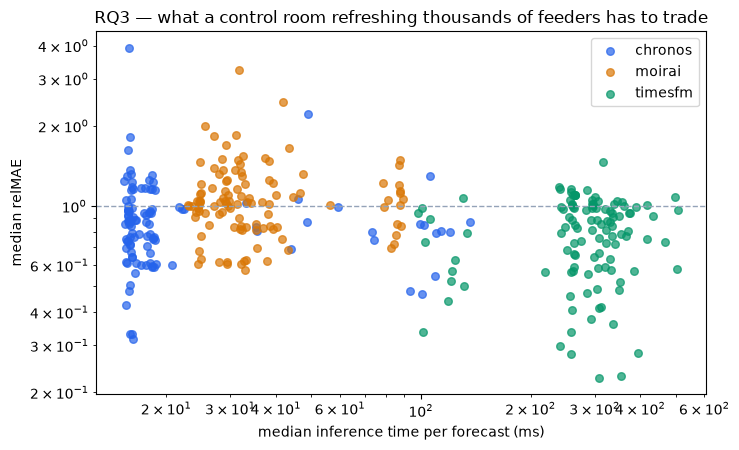

model
chronos     17.0
moirai      31.1
timesfm    277.3


In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for mdl, g in cfg.groupby("model"):
    ax.scatter(g.infer_sec*1000, g.median_relMAE, label=mdl, alpha=0.7, s=30,
               color=PALETTE.get(mdl))
ax.axhline(1.0, color="#94a3b8", ls="--", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("median inference time per forecast (ms)")
ax.set_ylabel("median relMAE"); ax.legend()
ax.set_title("RQ3 — what a control room refreshing thousands of feeders has to trade")
plt.tight_layout(); plt.show()

print(allres.groupby("model")["infer_sec"].median().mul(1000).round(1)
            .rename("median ms per forecast").to_string())

## 4. Does one model win everywhere? (H2)

In [13]:
print(C.mean_rank(allres, value="relMAE",
                  cell=("etype", "gran_label", "context_steps", "horizon_steps"))
        .round(3).to_string())
print()
w = C.winner_table(allres, value="relMAE", cell=("etype", "gran_label"))
print(w.to_string())
print("\nIf different models win different cells, single-vendor procurement is the")
print("wrong policy — and that is a finding an energy company can act on. Check it")
print("against refined_stage3e before claiming it: a win that is not significant is noise.")

         mean_rank  n_cells
model                      
timesfm      1.369      111
chronos      1.883      111
moirai       2.748      111

                       by_median  by_mean  best_median disagrees
etype gran_label                                                
load  daily              timesfm  timesfm        0.496          
      hourly             chronos  timesfm        0.632       yes
      minutes (native)   timesfm  timesfm        0.478          
solar daily              timesfm  timesfm        0.755          
      hourly             chronos  chronos        0.891          
      minutes (native)   timesfm  timesfm        1.028          
wind  daily              timesfm   moirai        0.951       yes
      hourly             timesfm  chronos        0.967       yes
      minutes (native)   timesfm  timesfm        0.593          

If different models win different cells, single-vendor procurement is the
wrong policy — and that is a finding an energy company can act on. Ch

## 5. Cold start — the commercial argument

A conventionally trained forecaster needs one to three years of history per site. Read
`C_deploy` from `refined_stage3b_context_requirements.csv` as the answer to *how soon after
commissioning is a usable forecast available* — that number, in days, is the argument for
foundation models in energy operations.

In [14]:
f = "refined_stage3b_context_requirements.csv"
if os.path.exists(f):
    req = pd.read_csv(f)
    print(req[["etype", "gran", "model", "C_deploy", "deploy_history",
               "C_saturate", "saturate_history", "best_relMAE"]].to_string(index=False))
else:
    print(f"{f} not found — run refined_stage3b_context_sweep first")

etype   gran   model  C_deploy deploy_history  C_saturate saturate_history  best_relMAE
 load     1D chronos     128.0        128.0 d         128          128.0 d        0.751
 load     1D  moirai     512.0        512.0 d         128          128.0 d        0.905
 load     1D timesfm     128.0        128.0 d        2048         2048.0 d        0.278
 load     1h chronos     128.0          5.3 d         128            5.3 d        0.708
 load     1h  moirai       NaN    never < 1.0         256           10.7 d        1.021
 load     1h timesfm     128.0          5.3 d         256           10.7 d        0.849
 load native chronos     128.0          2.7 d         128            2.7 d        0.590
 load native  moirai       NaN    never < 1.0         256            5.3 d        1.506
 load native timesfm     128.0          2.7 d         512           10.7 d        0.406
solar     1h chronos     128.0          5.3 d         256           10.7 d        0.937
solar     1h  moirai       NaN  